# 02 - S-N Curve Exploration

Explore the IIW bilinear S-N (Wöhler) curves for different FAT classes.

**Key formula:** $N = \left(\frac{\text{FAT}}{\Delta\sigma}\right)^m \times 2 \times 10^6$

- Below knee (N < 10^7): m = 3 (steel), m = 3.5 (aluminum)
- Above knee (N ≥ 10^7): m = 5 (steel, variable amplitude), m = 22 (steel, constant amplitude cutoff)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from weldfatigue.fatigue.sn_curve import SNCurve

## Compare Multiple FAT Classes

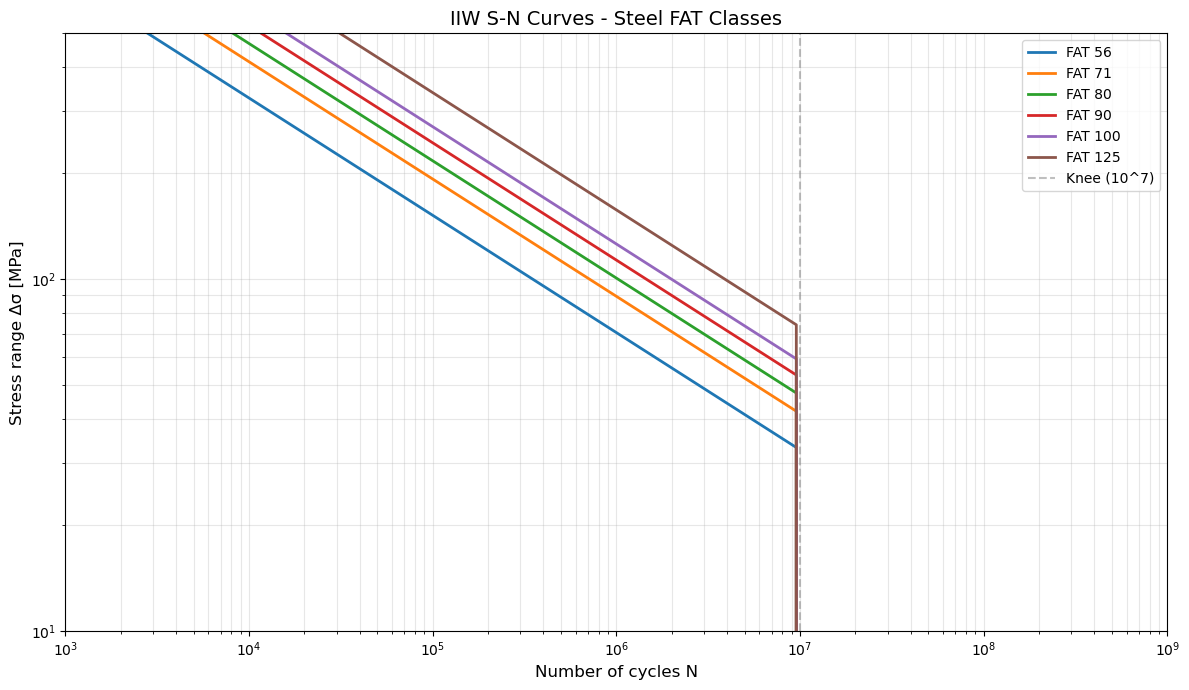

In [2]:
fat_classes = [56, 71, 80, 90, 100, 125]

fig, ax = plt.subplots(figsize=(12, 7))
for fc in fat_classes:
    sn = SNCurve(fat_class=fc, material_type="steel")
    n_vals, s_vals = sn.get_curve_points()
    ax.loglog(n_vals, s_vals, linewidth=2, label=f"FAT {fc}")

ax.axvline(x=1e7, color='gray', linestyle='--', alpha=0.5, label='Knee (10^7)')
ax.set_xlabel("Number of cycles N", fontsize=12)
ax.set_ylabel("Stress range Δσ [MPa]", fontsize=12)
ax.set_title("IIW S-N Curves - Steel FAT Classes", fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.3)
ax.set_xlim(1e3, 1e9)
ax.set_ylim(10, 500)
plt.tight_layout()
plt.show()

## Compute Allowable Cycles for a Given Stress Range

In [3]:
sn80 = SNCurve(fat_class=80, material_type="steel")

stress_ranges = [120, 100, 80, 60, 40]
print(f"{'Δσ [MPa]':>10}  {'N_allowable':>15}  {'Status at 2×10^6':>18}")
print("-" * 48)
for ds in stress_ranges:
    n_allow = sn80.cycles_to_failure(ds)
    status = "PASS" if n_allow >= 2e6 else "FAIL"
    print(f"{ds:>10.0f}  {n_allow:>15.0f}  {status:>18}")

  Δσ [MPa]      N_allowable    Status at 2×10^6
------------------------------------------------
       120           592593                FAIL
       100          1024000                FAIL
        80          2000000                PASS
        60          4740741                PASS
        40              inf                PASS


## Variable Amplitude vs Constant Amplitude

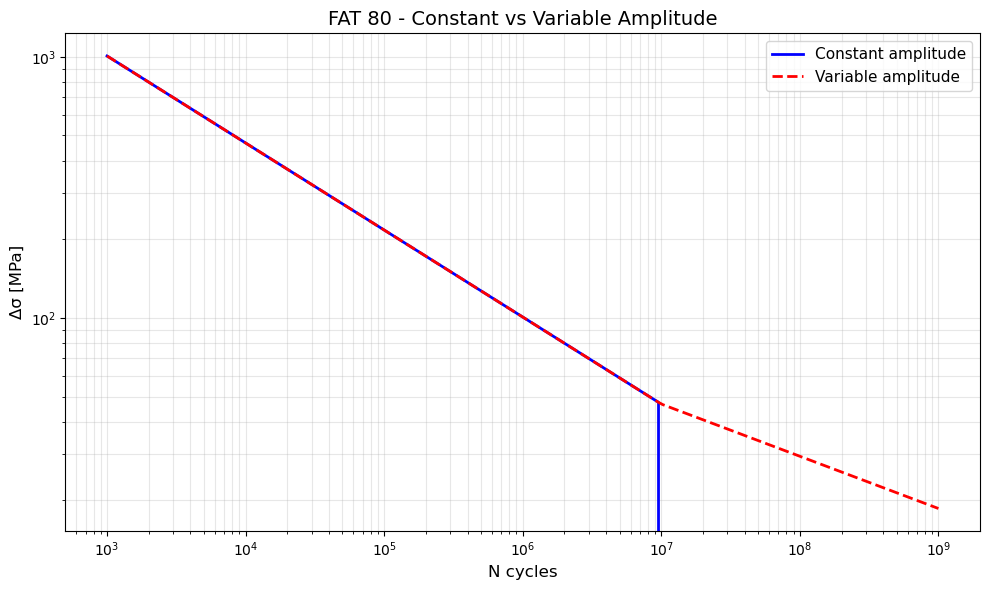

In [4]:
sn_ca = SNCurve(fat_class=80, material_type="steel", variable_amplitude=False)
sn_va = SNCurve(fat_class=80, material_type="steel", variable_amplitude=True)

fig, ax = plt.subplots(figsize=(10, 6))
n_ca, s_ca = sn_ca.get_curve_points()
n_va, s_va = sn_va.get_curve_points()
ax.loglog(n_ca, s_ca, 'b-', linewidth=2, label='Constant amplitude')
ax.loglog(n_va, s_va, 'r--', linewidth=2, label='Variable amplitude')
ax.set_xlabel("N cycles", fontsize=12)
ax.set_ylabel("Δσ [MPa]", fontsize=12)
ax.set_title("FAT 80 - Constant vs Variable Amplitude", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## Steel vs Aluminum S-N Curves

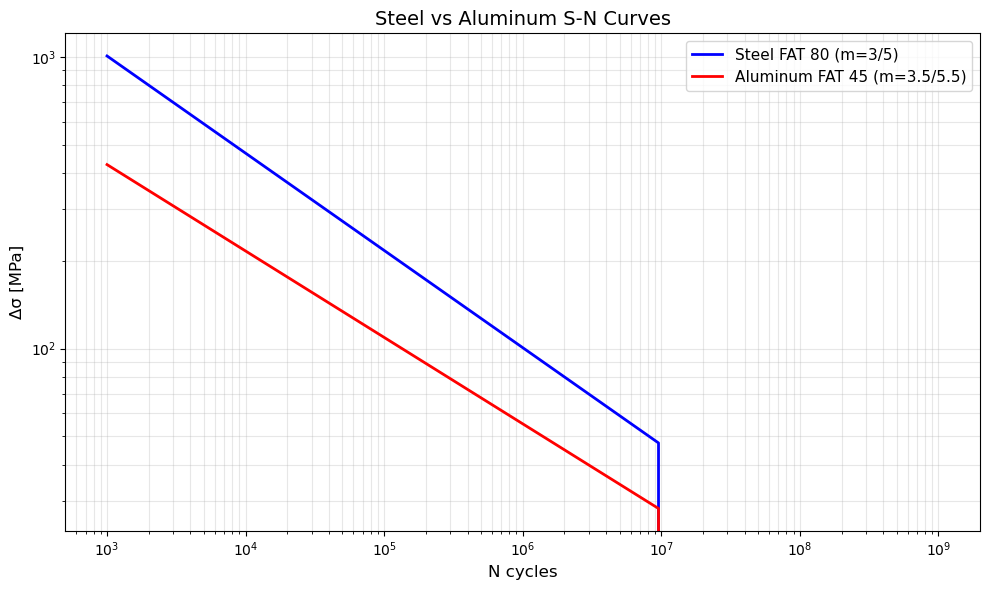

In [5]:
sn_steel = SNCurve(fat_class=80, material_type="steel")
sn_alum = SNCurve(fat_class=45, material_type="aluminum")

fig, ax = plt.subplots(figsize=(10, 6))
n_s, s_s = sn_steel.get_curve_points()
n_a, s_a = sn_alum.get_curve_points()
ax.loglog(n_s, s_s, 'b-', linewidth=2, label='Steel FAT 80 (m=3/5)')
ax.loglog(n_a, s_a, 'r-', linewidth=2, label='Aluminum FAT 45 (m=3.5/5.5)')
ax.set_xlabel("N cycles", fontsize=12)
ax.set_ylabel("Δσ [MPa]", fontsize=12)
ax.set_title("Steel vs Aluminum S-N Curves", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()